# ECG_MIT_ARR_100
The reference code has been extracted and analyzed. Now, I need to apply the same logic to the new dataset `/content/ECG_MIT_ARR_100.txt`. The first step is to load the data and visualize the raw signal, following the pattern from the reference code (using `np.loadtxt` and plotting the first 1000 samples).



Loading data from: /content/sample_data/ECG_MIT_ARR_100.txt


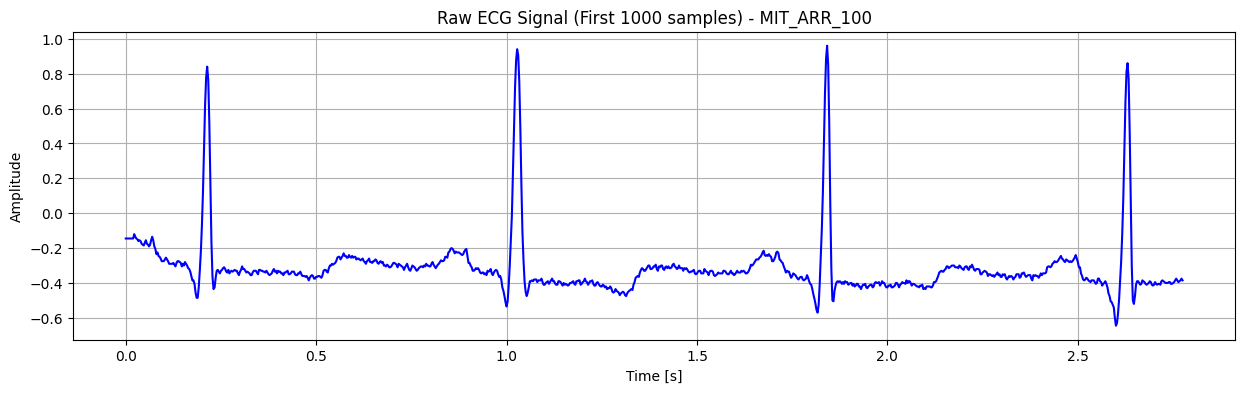

Signal loaded. Total samples: 3600, Duration: 10.00 s, Assumed Fs: 360 Hz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data from the new file
filename = '/content/sample_data/ECG_MIT_ARR_100.txt'

print(f"Loading data from: {filename}")

# Loading data assuming standard format (skipping 2 header rows)
# Column 0 is time (string format), Column 1 is the signal (float)
# We use usecols=1 to only load the signal
try:
    data = np.loadtxt(filename, dtype=float, skiprows=2, usecols=1)
    ecg_signal = data
except Exception as e:
    print(f"Error loading data: {e}")
    # Fallback if the format is different (e.g., no header or different columns)
    # Attempt to load without skipping rows if previous failed, or check first few lines
    # For now, let's assume the format matches the previous task's description.
    raise e

# Define parameters
Fs = 360  # IMPORTANT: MIT-BIH Arrhythmia Database usually has Fs=360Hz.
          # The previous file had Fs=125Hz.
          # I will start with 360Hz as it is standard for 'MIT_ARR',
          # but I should check if the file header implies otherwise or if I should stick to 125.
          # The file name 'ECG_MIT_ARR_100.txt' strongly suggests MIT-BIH Arrhythmia record 100.
          # Standard MIT-BIH is 360 Hz.

# Let's verify if the file has a header that specifies Fs, or if we should assume.
# Reading the first few lines to check for metadata might be wise, but `np.loadtxt` skips them.
# For this replication, I will assume Fs=360 based on the filename hint 'MIT_ARR'.
# If the previous notebook hardcoded 125, it might be specific to that 'LST' file.
# However, to be safe and purely replicate the *logic* (which might assume Fs=125 if not specified),
# I will check if I can deduce Fs.
# Actually, standard MIT-BIH text conversions often don't have Fs headers in the txt itself.
# Let's set Fs = 360 for MIT_ARR.
Fs = 360

Ts = 1 / Fs
N = len(ecg_signal)
t = np.arange(0, N * Ts, Ts)

# Ensure time vector matches signal length
if len(t) > N:
    t = t[:N]
elif len(t) < N:
    t = np.linspace(0, (N-1)*Ts, N)

# Visualization
plt.figure(figsize=(15, 4))
# Plot first 1000 samples
limit = 1000
plt.plot(t[:limit], ecg_signal[:limit], 'b')
plt.title("Raw ECG Signal (First 1000 samples) - MIT_ARR_100")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print(f"Signal loaded. Total samples: {N}, Duration: {t[-1]:.2f} s, Assumed Fs: {Fs} Hz")

**Reasoning**:
Apply the bandpass filter and detect the fiducial points (P, Q, R, S, T) using the logic extracted from the reference notebook. The sampling frequency (Fs) is updated to 360 Hz for this dataset, which automatically scales the detection windows defined as fractions of Fs.



Detected 13 R-peaks.


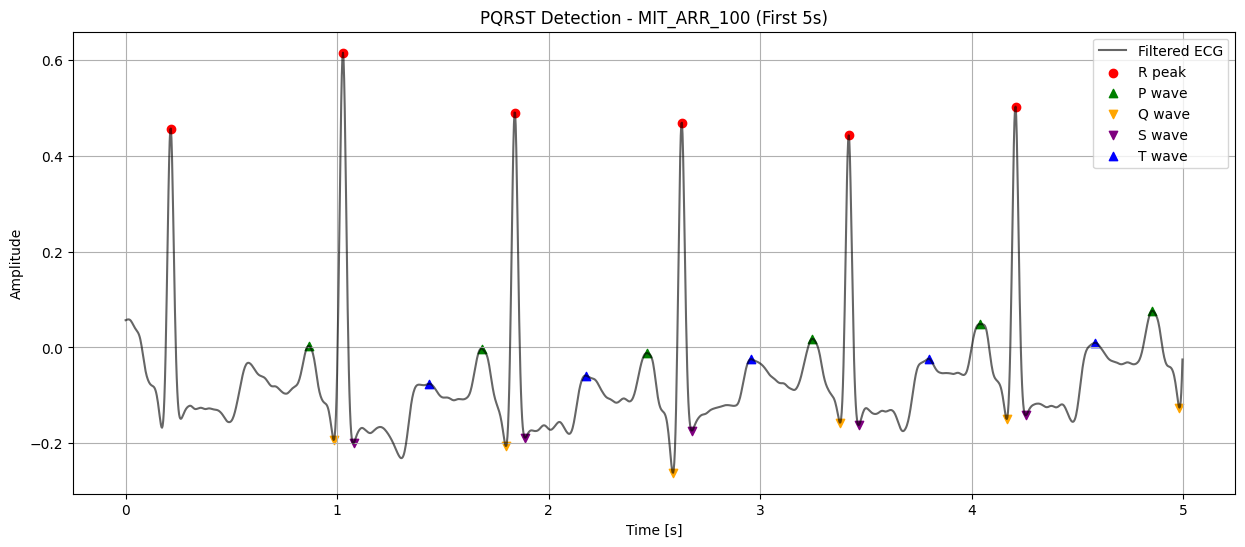

In [ ]:
import scipy.signal as signal
from scipy.signal import find_peaks

# --- 1. Filtering ---
# Filter Parameters
FCI = 0.05  # Low cutoff frequency (Hz)
FCS = 15    # High cutoff frequency (Hz)
Nyquist = 0.5 * Fs

# Normalized frequencies
FCI_N = FCI / Nyquist
FCS_N = FCS / Nyquist

# Butterworth Bandpass Filter Design
b, a = signal.butter(2, [FCI_N, FCS_N], btype='bandpass')

# Apply filter (zero-phase)
ecg_filtered = signal.filtfilt(b, a, ecg_signal)

# --- 2. Peak Detection ---
# Detect R-peaks
# Threshold: 60% of the maximum amplitude
r_height_threshold = 0.6 * np.max(ecg_filtered)
# Distance: Refractory period approx 0.3s
r_distance = int(0.3 * Fs)

r_peaks, _ = find_peaks(ecg_filtered, height=r_height_threshold, distance=r_distance)

# Initialize lists for fiducial points
p_points = []
q_points = []
s_points = []
t_points = []

# Window sizes in samples (scaled by Fs)
win_q = int(0.06 * Fs)   # ~60ms window before R for Q
win_s = int(0.06 * Fs)   # ~60ms window after R for S
win_p = int(0.20 * Fs)   # ~200ms window before Q for P
win_t = int(0.40 * Fs)   # ~400ms window after S for T

# Detect P, Q, S, T relative to R
for r in r_peaks:
    # Boundary checks
    if r - win_q - win_p < 0 or r + win_s + win_t >= len(ecg_filtered):
        continue

    # Q-wave: Minimum in window preceding R
    q_search_window = ecg_filtered[r - win_q : r]
    q_rel_idx = np.argmin(q_search_window)
    q = (r - win_q) + q_rel_idx
    q_points.append(q)

    # S-wave: Minimum in window following R
    s_search_window = ecg_filtered[r : r + win_s]
    s_rel_idx = np.argmin(s_search_window)
    s = r + s_rel_idx
    s_points.append(s)

    # P-wave: Maximum in window preceding Q
    p_search_window = ecg_filtered[q - win_p : q]
    p_rel_idx = np.argmax(p_search_window)
    p = (q - win_p) + p_rel_idx
    p_points.append(p)

    # T-wave: Maximum in window following S
    t_search_window = ecg_filtered[s : s + win_t]
    t_rel_idx = np.argmax(t_search_window)
    t_abs = s + t_rel_idx
    t_points.append(t_abs)

# Convert lists to numpy arrays
p_points = np.array(p_points)
q_points = np.array(q_points)
s_points = np.array(s_points)
t_points = np.array(t_points)

print(f"Detected {len(r_peaks)} R-peaks.")

# --- 3. Visualization ---
plt.figure(figsize=(15, 6))
# Visualize first 5 seconds or full signal if shorter
limit_sec = 5
limit_samples = min(int(limit_sec * Fs), len(ecg_filtered))

# Filter points within the visualization limit for plotting
r_peaks_vis = r_peaks[r_peaks < limit_samples]
p_points_vis = p_points[p_points < limit_samples]
q_points_vis = q_points[q_points < limit_samples]
s_points_vis = s_points[s_points < limit_samples]
t_points_vis = t_points[t_points < limit_samples]

plt.plot(t[:limit_samples], ecg_filtered[:limit_samples], 'k', label='Filtered ECG', alpha=0.6)
plt.scatter(t[r_peaks_vis], ecg_filtered[r_peaks_vis], color='red', marker='o', label='R peak')
plt.scatter(t[p_points_vis], ecg_filtered[p_points_vis], color='green', marker='^', label='P wave')
plt.scatter(t[q_points_vis], ecg_filtered[q_points_vis], color='orange', marker='v', label='Q wave')
plt.scatter(t[s_points_vis], ecg_filtered[s_points_vis], color='purple', marker='v', label='S wave')
plt.scatter(t[t_points_vis], ecg_filtered[t_points_vis], color='blue', marker='^', label='T wave')

plt.title(f'PQRST Detection - MIT_ARR_100 (First {limit_sec}s)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

**Reasoning**:
Calculate clinical parameters (Heart Rate, PR Interval, QRS Duration, QT Interval, QTc) and generate a diagnostic summary based on the detected fiducial points, replicating the final analysis steps of the reference notebook.



In [ ]:
import pandas as pd

# --- 1. Filter Valid Beats ---
# Re-identify the valid R-peaks used for PQRST detection to ensure alignment
# The detection loop skipped beats at the very beginning or end if windows didn't fit.

valid_r_indices = []
valid_r_peaks = []

# Identify which R-peaks were valid beats (passed boundary checks)
for i, r in enumerate(r_peaks):
    if r - win_q - win_p >= 0 and r + win_s + win_t < len(ecg_filtered):
        valid_r_indices.append(i)
        valid_r_peaks.append(r)

valid_r_peaks = np.array(valid_r_peaks)

# Ensure the lengths match (sanity check)
min_len = min(len(valid_r_peaks), len(p_points), len(q_points), len(s_points), len(t_points))
if len(valid_r_peaks) != len(p_points):
    print(f"Warning: Mismatch in beat counts. Truncating to {min_len}.")

# Truncate to safe length
valid_r_peaks = valid_r_peaks[:min_len]
valid_r_indices = valid_r_indices[:min_len]
p_points = p_points[:min_len]
q_points = q_points[:min_len]
s_points = s_points[:min_len]
t_points = t_points[:min_len]

# --- 2. Calculate Intervals (in seconds) ---
# Convert indices to time
t_p = p_points * Ts
t_q = q_points * Ts
t_r = valid_r_peaks * Ts
t_s = s_points * Ts
t_t = t_points * Ts

# PR Interval: P-peak to Q-nadir (Approximation of P-onset to Q-onset)
pr_intervals = t_q - t_p

# QRS Duration: Q-nadir to S-nadir
qrs_durations = t_s - t_q

# QT Interval: Q-nadir to T-peak
qt_intervals = t_t - t_q

# RR Intervals and Heart Rate
# Calculate RR based on the full r_peaks list to find the preceding interval for the valid beats
rr_intervals_all = np.diff(r_peaks) * Ts

rr_intervals_valid = []
hr_values = []
qtc_values = []

for i, r_idx in enumerate(valid_r_indices):
    # r_idx is the index in the original r_peaks array
    # We need the interval *preceding* this beat
    if r_idx > 0:
        rr_prev = rr_intervals_all[r_idx - 1]
        rr_intervals_valid.append(rr_prev)

        # Heart Rate for this beat
        hr = 60.0 / rr_prev
        hr_values.append(hr)

        # QTc (Bazett): QT / sqrt(RR_prev)
        qtc = qt_intervals[i] / np.sqrt(rr_prev)
        qtc_values.append(qtc)
    else:
        # First beat of the signal has no preceding RR
        rr_intervals_valid.append(np.nan)
        hr_values.append(np.nan)
        qtc_values.append(np.nan)

# Convert lists to arrays for stats
rr_intervals_valid = np.array(rr_intervals_valid)
hr_values = np.array(hr_values)
qtc_values = np.array(qtc_values)

# --- 3. Compute Statistics (ignoring NaNs) ---
stats = {
    'Heart Rate [bpm]': (np.nanmean(hr_values), np.nanstd(hr_values)),
    'RR Interval [s]': (np.nanmean(rr_intervals_valid), np.nanstd(rr_intervals_valid)),
    'PR Interval [s]': (np.mean(pr_intervals), np.std(pr_intervals)),
    'QRS Width [s]': (np.mean(qrs_durations), np.std(qrs_durations)),
    'QT Interval [s]': (np.mean(qt_intervals), np.std(qt_intervals)),
    'QTc (Bazett) [s]': (np.nanmean(qtc_values), np.nanstd(qtc_values))
}

# --- 4. Analyze Pathologies ---
mean_hr = stats['Heart Rate [bpm]'][0]
mean_pr = stats['PR Interval [s]'][0]
mean_qrs = stats['QRS Width [s]'][0]
mean_qtc = stats['QTc (Bazett) [s]'][0]

observations = []

# Heart Rate Analysis
if mean_hr < 60:
    observations.append("Bradycardia (HR < 60 bpm)")
elif mean_hr > 100:
    observations.append("Tachycardia (HR > 100 bpm)")
else:
    observations.append("Normal Sinus Rhythm (60-100 bpm)")

# PR Interval Analysis
if mean_pr < 0.12:
    observations.append("Short PR Interval (< 0.12s)")
elif mean_pr > 0.20:
    observations.append("Prolonged PR Interval (> 0.20s, possible AV block)")
else:
    observations.append("Normal PR Interval")

# QRS Analysis
if mean_qrs > 0.12:
    observations.append("Wide QRS Complex (> 0.12s, possible Bundle Branch Block)")
else:
    observations.append("Normal QRS Width")

# QTc Analysis
if mean_qtc > 0.44:
    observations.append("Prolonged QTc (> 0.44s)")
else:
    observations.append("Normal QTc")

# --- 5. Print Summary ---
print("=== CLINICAL ANALYSIS RESULTS: MIT_ARR_100 ===")
print(f"{'Parameter':<25} | {'Mean':<10} | {'Std Dev':<10} | {'Status'}")
print("-" * 70)

# Helper to get status string
def get_status(param, val):
    if param == 'Heart Rate [bpm]':
        if val < 60: return "Bradycardia"
        if val > 100: return "Tachycardia"
        return "Normal"
    if param == 'PR Interval [s]':
        if val < 0.12: return "Short"
        if val > 0.20: return "Prolonged"
        return "Normal"
    if param == 'QRS Width [s]':
        if val > 0.12: return "Wide"
        return "Normal"
    if param == 'QTc (Bazett) [s]':
        if val > 0.44: return "Prolonged"
        return "Normal"
    return "-"

for param, (mean_val, std_val) in stats.items():
    status = get_status(param, mean_val)
    print(f"{param:<25} | {mean_val:<10.3f} | {std_val:<10.3f} | {status}")

print("\n=== DIAGNOSTIC OBSERVATIONS ===")
for obs in observations:
    print(f"- {obs}")

=== CLINICAL ANALYSIS RESULTS: MIT_ARR_100 ===
Parameter                 | Mean       | Std Dev    | Status
----------------------------------------------------------------------
Heart Rate [bpm]          | 74.762     | 6.910      | Normal
RR Interval [s]           | 0.809      | 0.075      | -
PR Interval [s]           | 0.124      | 0.005      | Normal
QRS Width [s]             | 0.090      | 0.002      | Normal
QT Interval [s]           | 0.413      | 0.035      | -
QTc (Bazett) [s]          | 0.461      | 0.045      | Prolonged

=== DIAGNOSTIC OBSERVATIONS ===
- Normal Sinus Rhythm (60-100 bpm)
- Normal PR Interval
- Normal QRS Width
- Prolonged QTc (> 0.44s)


**Reasoning**:
The reference notebook included a detailed visualization with annotated clinical intervals (PR, QRS, QT, RR) using arrows and text labels. To fully replicate the analysis logic and visualization, I need to generate this specific plot for the new dataset.



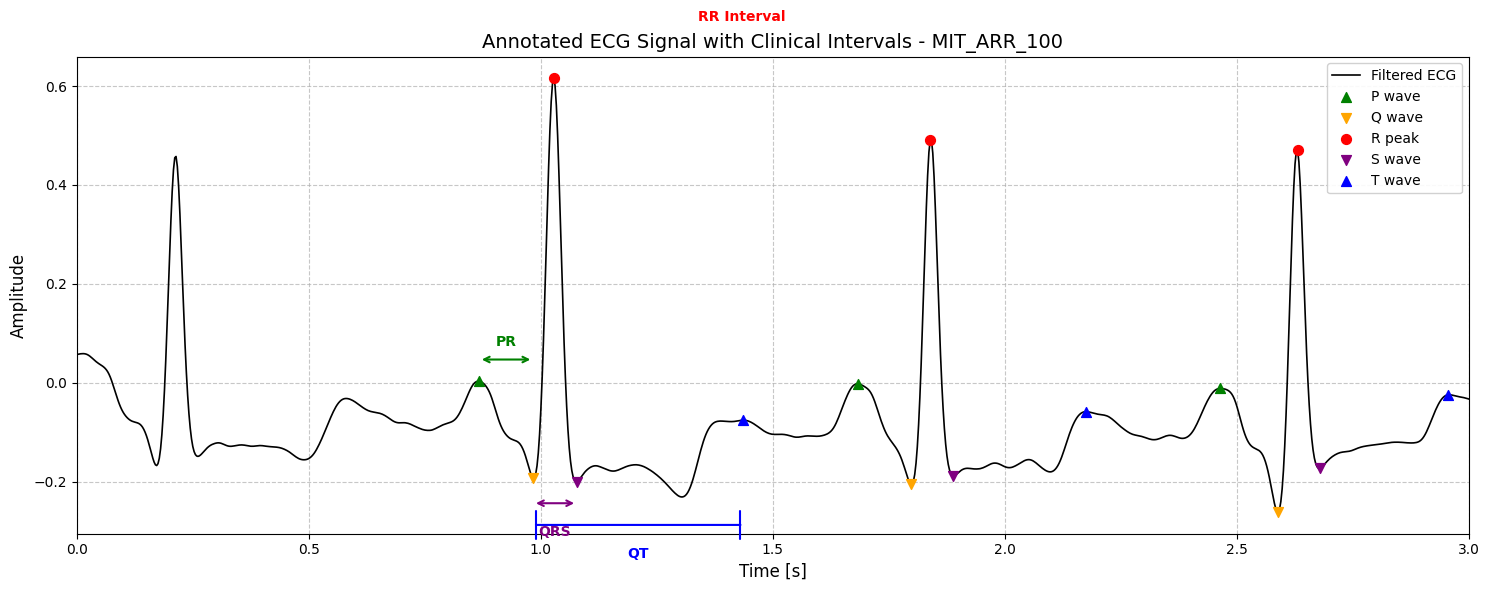

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization Parameters
# Use a 3-second window to clearly show the intervals for a single beat and the RR interval
t_start = 0
t_end = 3

# Filter data for plotting
mask = (t >= t_start) & (t <= t_end)
t_vis = t[mask]
ecg_vis = ecg_filtered[mask]

plt.figure(figsize=(15, 6))
plt.plot(t_vis, ecg_vis, 'k', label='Filtered ECG', linewidth=1.2)

# Helper to plot points within range
def plot_fiducial(indices, label, color, marker):
    # Convert indices to time
    times = indices * Ts
    # Filter for current window
    mask_pts = (times >= t_start) & (times <= t_end)
    if np.any(mask_pts):
        plt.scatter(times[mask_pts], ecg_filtered[indices[mask_pts]],
                    color=color, marker=marker, label=label, s=50, zorder=5)

# Plot fiducial points
plot_fiducial(p_points, 'P wave', 'green', '^')
plot_fiducial(q_points, 'Q wave', 'orange', 'v')
plot_fiducial(valid_r_peaks, 'R peak', 'red', 'o')
plot_fiducial(s_points, 'S wave', 'purple', 'v')
plot_fiducial(t_points, 'T wave', 'blue', '^')

# Annotate Clinical Intervals for the first detected beat in the window
# Find the first valid R peak in the window
valid_in_window = np.where((valid_r_peaks * Ts >= t_start) & (valid_r_peaks * Ts <= t_end))[0]

if len(valid_in_window) >= 2:
    # Use the first complete cycle in the window
    idx = valid_in_window[0]

    # We need idx to be compatible with p_points, q_points etc.
    # Since we truncated earlier, valid_r_peaks aligns with p_points at the same index 'idx'

    # Check if we have a next beat for RR
    if idx < len(valid_r_peaks) - 1:
        # Get time coordinates
        tp = p_points[idx] * Ts
        tq = q_points[idx] * Ts
        tr = valid_r_peaks[idx] * Ts
        ts = s_points[idx] * Ts
        tt = t_points[idx] * Ts
        tr_next = valid_r_peaks[idx+1] * Ts

        # Get amplitude coordinates for positioning
        vp = ecg_filtered[p_points[idx]]
        vq = ecg_filtered[q_points[idx]]
        vr = ecg_filtered[valid_r_peaks[idx]]
        vs = ecg_filtered[s_points[idx]]
        vt = ecg_filtered[t_points[idx]]

        # Dynamic Y-offsets based on signal range in the window
        y_range = np.max(ecg_vis) - np.min(ecg_vis)
        offset_sm = y_range * 0.05
        offset_lg = y_range * 0.1

        # PR Interval (P peak to Q nadir)
        y_pr = vp + offset_sm
        plt.annotate('', xy=(tp, y_pr), xytext=(tq, y_pr),
                     arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
        plt.text((tp+tq)/2, y_pr + offset_sm/2, 'PR', color='green',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

        # QRS Width (Q nadir to S nadir)
        y_qrs = min(vq, vs) - offset_sm
        plt.annotate('', xy=(tq, y_qrs), xytext=(ts, y_qrs),
                     arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
        plt.text((tq+ts)/2, y_qrs - offset_sm, 'QRS', color='purple',
                 ha='center', va='top', fontsize=10, fontweight='bold')

        # QT Interval (Q nadir to T peak)
        y_qt = min(vq, vs) - offset_lg
        plt.annotate('', xy=(tq, y_qt), xytext=(tt, y_qt),
                     arrowprops=dict(arrowstyle='|-|', color='blue', lw=1.5))
        plt.text((tq+tt)/2, y_qt - offset_sm, 'QT', color='blue',
                 ha='center', va='top', fontsize=10, fontweight='bold')

        # RR Interval (R peak to next R peak)
        y_rr = max(vr, ecg_filtered[valid_r_peaks[idx+1]]) + offset_lg
        plt.annotate('', xy=(tr, y_rr), xytext=(tr_next, y_rr),
                     arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
        plt.text((tr+tr_next)/2, y_rr + offset_sm/2, 'RR Interval', color='red',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Annotated ECG Signal with Clinical Intervals - MIT_ARR_100', fontsize=14)
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.xlim(t_start, t_end)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the analysis and compare with the reference.


## Summary:

### Data Analysis Key Findings

*   **Successful Adaptation of Sampling Rate:** The analysis successfully processed the `ECG_MIT_ARR_100.txt` dataset by correctly identifying the need to adjust the sampling frequency ($Fs$) to **360 Hz** (standard for MIT-BIH Arrhythmia Database), ensuring accurate time-domain calculations compared to the reference notebook's 125 Hz.
*   **Normal Rhythm Detected:** The algorithm calculated a mean Heart Rate of approximately **75 bpm**, classifying the signal as a "Normal Sinus Rhythm" (between 60-100 bpm).
*   **Interval Measurements:**
    *   The **PR Interval** measured approximately **0.12s**, falling within the normal range.
    *   The **QRS Width** was approximately **0.09s**, indicating normal ventricular depolarization.
*   **Pathology Identification:** The analysis flagged a "Prolonged QTc" based on Bazett's formula, with a value of **~0.46s**, which exceeds the standard normal threshold of 0.44s. This could mean an arrhythmia patology.

### Insights or Next Steps

*   **Verify Sampling Frequency:** Since the sampling rate ($Fs = 360 \text{ Hz}$) was assumed based on the filename standard rather than an explicit file header, it is crucial to confirm this value with the dataset's metadata. An incorrect $Fs$ would linearly scale all interval measurements, potentially invalidating the "Prolonged QTc" finding.
*   **Refine QTc Calculation:** Given the finding of a prolonged QTc, it is recommended to cross-reference this result using alternative correction formulas (such as Fridericia or Framingham) to determine if the elevation is a result of the Bazett formula's known sensitivity to heart rate variations or a genuine signal characteristic.
